# ex999_Thermal_ReactiveColumn1D

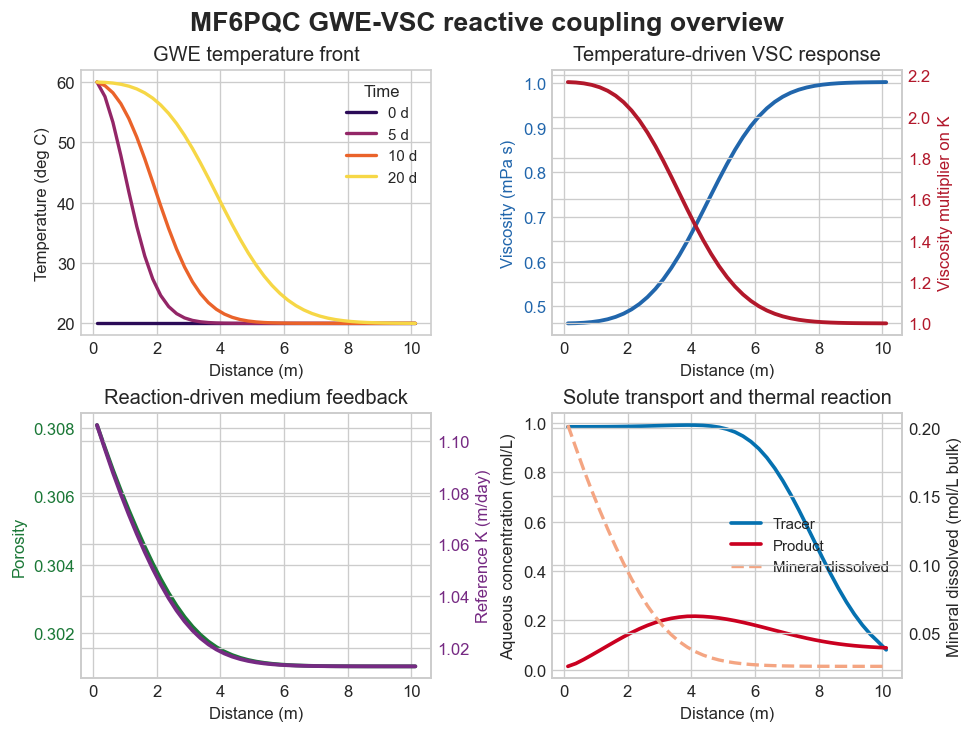

,field,final minimum,final maximum
0,Temperature (deg C),20.000000,60.000000
1,Viscosity (mPa s),0.462214,1.001600
2,Porosity,0.301019,0.308086
3,Reference K (m/day),1.012847,1.106150
4,Effective K (m/day),1.012847,2.396987


,Maximum error
Metric,
maximum VSC identity error,4.44089e-16
maximum explicit-lag error,0
maximum GWE-to-reaction temperature error,0


In [8]:
import sys
from pathlib import Path

sys.dont_write_bytecode = True
CASE_DIR = next(
    p
    for root in (Path.cwd(), *Path.cwd().parents)
    for p in (root, root / "examples/ex999_Thermal_ReactiveColumn1D")
    if p.name == "ex999_Thermal_ReactiveColumn1D" and (p / "run.py").is_file()
)
sys.path.insert(0, str(CASE_DIR.parent))
from example_utils import load_results, runtime_path

CASE_FILE = CASE_DIR / "run.py"
INPUT_DIR = CASE_DIR / "input_data"
OUTPUT_DIR = runtime_path(CASE_FILE, "output")
SIMULATION_DIR = runtime_path(CASE_FILE, "simulation")
import json

import flopy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 220,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)
EXAMPLE_DIR = CASE_DIR
FIGURE_DIR = OUTPUT_DIR / "figures"
from IPython.display import display

results, headings, times = load_results(OUTPUT_DIR)
temperature = np.load(OUTPUT_DIR / "results_temperature.npy")
temperature_for_flow = np.load(OUTPUT_DIR / "results_temperature_for_flow.npy")
viscosity = np.load(OUTPUT_DIR / "results_viscosity.npy")
reference_k = np.load(OUTPUT_DIR / "results_reference_K.npy")
effective_k = np.load(OUTPUT_DIR / "results_effective_K.npy")
porosity = np.load(OUTPUT_DIR / "results_porosity.npy")
manifest = json.loads((OUTPUT_DIR / "results_manifest.json").read_text(encoding="utf-8"))


def selected_output(name):
    return results[:, headings.index(name), :]


tracer = selected_output("Tracer")
product = selected_output("Product")
mineral = selected_output("ThermalMineral")
arrhenius_factor = selected_output("ArrheniusFactor")
mineral_loss = mineral[0] - mineral
ncell = results.shape[2]
cell_width_m = 0.25
x = (np.arange(ncell) + 0.5) * cell_width_m
summary = pd.DataFrame(
    {
        "field": [
            "Temperature (deg C)",
            "Viscosity (mPa s)",
            "Porosity",
            "Reference K (m/day)",
            "Effective K (m/day)",
        ],
        "final minimum": [
            temperature[-1].min(),
            viscosity[-1].min() * 1000.0,
            porosity[-1].min(),
            reference_k[-1].min(),
            effective_k[-1].min(),
        ],
        "final maximum": [
            temperature[-1].max(),
            viscosity[-1].max() * 1000.0,
            porosity[-1].max(),
            reference_k[-1].max(),
            effective_k[-1].max(),
        ],
    }
)
viscosity_reference = 0.0010016
vsc_error = np.max(np.abs(effective_k - reference_k * viscosity_reference / viscosity))
thermal_lag_error = np.max(np.abs(temperature_for_flow[1:] - temperature[:-1]))
arrhenius_expected = np.exp(-45000.0 / 8.314462618 * (1.0 / (temperature + 273.15) - 1.0 / 293.15))
reaction_temperature_error = np.max(np.abs(arrhenius_factor - arrhenius_expected))
error_summary = (
    pd.Series(
        {
            "maximum VSC identity error": vsc_error,
            "maximum explicit-lag error": thermal_lag_error,
            "maximum GWE-to-reaction temperature error": reaction_temperature_error,
        }
    )
    .rename_axis("Metric")
    .to_frame("Maximum error")
)
profile_times = [0.0, 5.0, 10.0, 20.0]
profile_indices = [int(np.argmin(np.abs(times - value))) for value in profile_times]
colors = plt.cm.inferno(np.linspace(0.15, 0.9, len(profile_indices)))
fig, axes = plt.subplots(2, 2, figsize=(8, 6.0), constrained_layout=True)
for index, color in zip(profile_indices, colors, strict=False):
    axes[0, 0].plot(x, temperature[index], color=color, lw=2, label=f"{times[index]:g} d")
axes[0, 0].set(title="GWE temperature front", xlabel="Distance (m)", ylabel="Temperature (deg C)")
axes[0, 0].legend(title="Time")
axes[0, 1].plot(x, viscosity[-1] * 1000.0, color="#2166ac", lw=2.3, label="Viscosity")
axes[0, 1].set(
    title="Temperature-driven VSC response", xlabel="Distance (m)", ylabel="Viscosity (mPa s)"
)
axes[0, 1].yaxis.label.set_color("#2166ac")
axes[0, 1].tick_params(axis="y", labelcolor="#2166ac")
axis_k_ratio = axes[0, 1].twinx()
axis_k_ratio.plot(
    x, effective_k[-1] / reference_k[-1], color="#b2182b", lw=2.3, label="K effective / K reference"
)
axis_k_ratio.set_ylabel("Viscosity multiplier on K", color="#b2182b")
axis_k_ratio.tick_params(axis="y", labelcolor="#b2182b")
axes[1, 0].plot(x, porosity[-1], color="#1b7837", lw=2.3, label="Porosity")
axes[1, 0].set(title="Reaction-driven medium feedback", xlabel="Distance (m)", ylabel="Porosity")
axes[1, 0].yaxis.label.set_color("#1b7837")
axes[1, 0].tick_params(axis="y", labelcolor="#1b7837")
axis_reference_k = axes[1, 0].twinx()
axis_reference_k.plot(x, reference_k[-1], color="#762a83", lw=2.3, label="Reference K")
axis_reference_k.set_ylabel("Reference K (m/day)", color="#762a83")
axis_reference_k.tick_params(axis="y", labelcolor="#762a83")
axes[1, 1].plot(x, tracer[-1], color="#0571b0", lw=2.2, label="Tracer")
axes[1, 1].plot(x, product[-1], color="#ca0020", lw=2.2, label="Product")
axes[1, 1].set(
    title="Solute transport and thermal reaction",
    xlabel="Distance (m)",
    ylabel="Aqueous concentration (mol/L)",
)
axis_mineral = axes[1, 1].twinx()
axis_mineral.plot(x, mineral_loss[-1], color="#f4a582", lw=2.0, ls="--", label="Mineral dissolved")
axis_mineral.set_ylabel("Mineral dissolved (mol/L bulk)")
lines_a, labels_a = axes[1, 1].get_legend_handles_labels()
lines_b, labels_b = axis_mineral.get_legend_handles_labels()
axes[1, 1].legend(lines_a + lines_b, labels_a + labels_b, loc="center right")
fig.suptitle("MF6PQC GWE-VSC reactive coupling overview", fontsize=16, fontweight="bold")
plt.show()
display(summary.round(6))
display(error_summary.style.format("{:.6g}"))

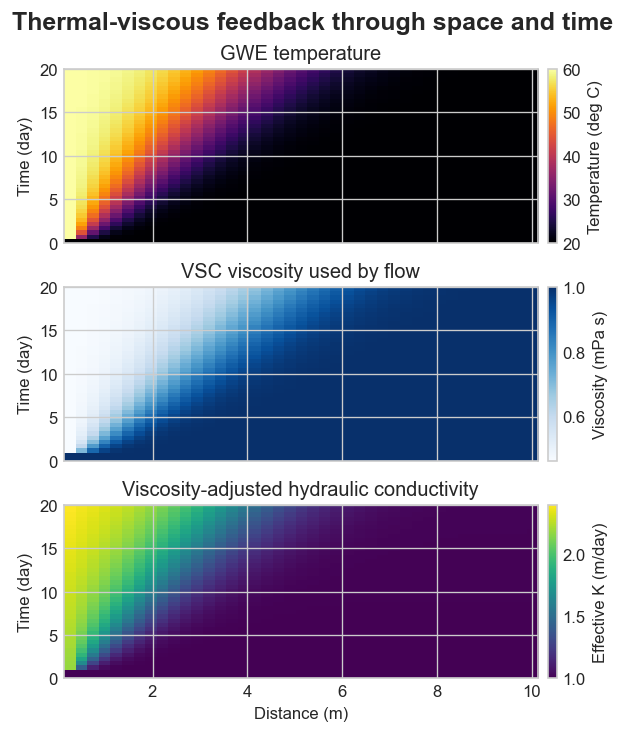

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(5, 6), sharex=True, constrained_layout=True)
heatmaps = [
    (temperature, "inferno", "Temperature (deg C)", "GWE temperature"),
    (viscosity * 1000.0, "Blues", "Viscosity (mPa s)", "VSC viscosity used by flow"),
    (effective_k, "viridis", "Effective K (m/day)", "Viscosity-adjusted hydraulic conductivity"),
]
for axis, (values, cmap, colorbar_label, title) in zip(axes, heatmaps, strict=False):
    image = axis.imshow(
        values,
        origin="lower",
        aspect="auto",
        cmap=cmap,
        extent=[x[0], x[-1], times[0], times[-1]],
        interpolation="nearest",
    )
    axis.set_ylabel("Time (day)")
    axis.set_title(title)
    fig.colorbar(image, ax=axis, pad=0.015, label=colorbar_label)
axes[-1].set_xlabel("Distance (m)")
fig.suptitle("Thermal-viscous feedback through space and time", fontsize=15, fontweight="bold")
plt.show()

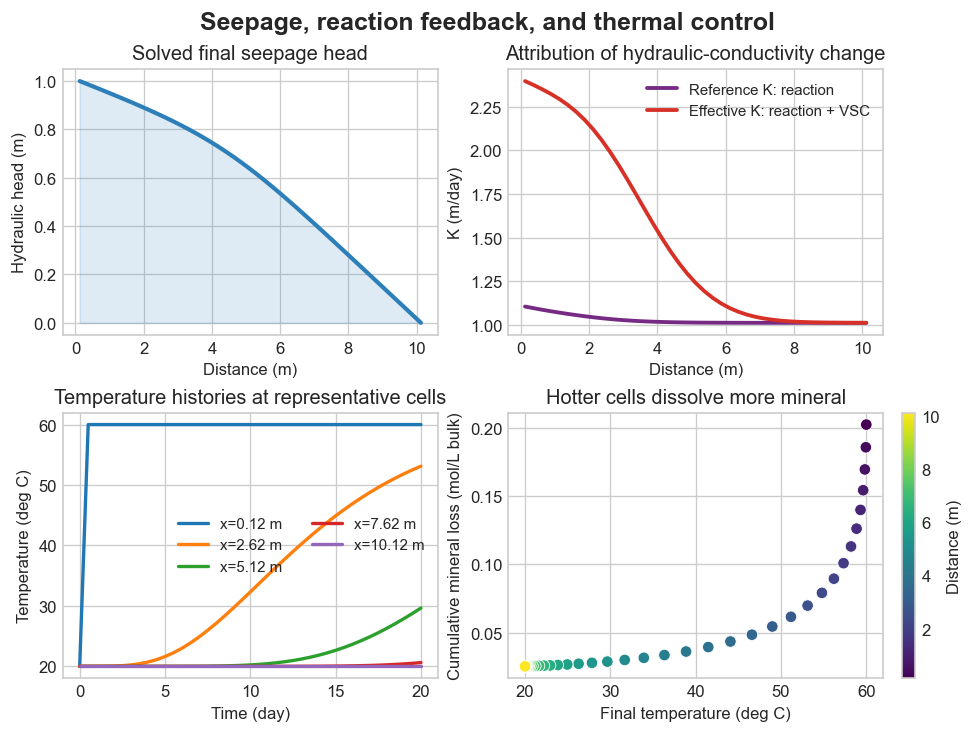

In [9]:
head_file = flopy.utils.HeadFile(SIMULATION_DIR / "gwf_model.hds")
final_head = np.asarray(head_file.get_data(totim=float(times[-1]))).ravel()
representative_cells = [0, 10, 20, 30, 40]
fig, axes = plt.subplots(2, 2, figsize=(8, 6.0), constrained_layout=True)
axes[0, 0].plot(x, final_head, color="#2c7fb8", lw=2.5)
axes[0, 0].fill_between(x, final_head, alpha=0.15, color="#2c7fb8")
axes[0, 0].set(
    title="Solved final seepage head", xlabel="Distance (m)", ylabel="Hydraulic head (m)"
)
axes[0, 1].plot(x, reference_k[-1], color="#762a83", lw=2.3, label="Reference K: reaction")
axes[0, 1].plot(x, effective_k[-1], color="#d73027", lw=2.3, label="Effective K: reaction + VSC")
axes[0, 1].set(
    title="Attribution of hydraulic-conductivity change", xlabel="Distance (m)", ylabel="K (m/day)"
)
axes[0, 1].legend()
for cell in representative_cells:
    axes[1, 0].plot(times, temperature[:, cell], lw=2, label=f"x={x[cell]:.2f} m")
axes[1, 0].set(
    title="Temperature histories at representative cells",
    xlabel="Time (day)",
    ylabel="Temperature (deg C)",
)
axes[1, 0].legend(ncol=2)
scatter = axes[1, 1].scatter(
    temperature[-1], mineral_loss[-1], c=x, cmap="viridis", s=48, edgecolor="white", linewidth=0.5
)
axes[1, 1].set(
    title="Hotter cells dissolve more mineral",
    xlabel="Final temperature (deg C)",
    ylabel="Cumulative mineral loss (mol/L bulk)",
)
fig.colorbar(scatter, ax=axes[1, 1], label="Distance (m)")
fig.suptitle("Seepage, reaction feedback, and thermal control", fontsize=15, fontweight="bold")
plt.show()